<a href="https://colab.research.google.com/github/TahaMirza50/Face-Detection-And-Recognition-App/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Preprocessing

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Install & Mount Drive
# ─────────────────────────────────────────────────────────────────

In [ ]:

!pip install opencv-python-headless --quiet

from google.colab import drive
drive.mount('/content/drive')
print(" Drive mounted.")

Mounted at /content/drive
 Drive mounted.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — CONFIGURATION  ← only edit this cell
# ─────────────────────────────────────────────────────────────────

In [ ]:


DATASET_DIR = "/content/drive/MyDrive/dataset"   # ← your dataset folder
LOCAL_OUT   = "/content/processed"                           # fast local working dir
DRIVE_OUT   = "/content/drive/MyDrive/Applied AI/processed" # final save to Drive

IMG_SIZE    = (128, 128)  # all faces resized to this
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

print(" Config set.")

 Config set.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ─────────────────────────────────────────────────────────────────

In [ ]:
import os, random, shutil, cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

CASCADE_PATH = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
print(f"OpenCV {cv2.__version__} ready.")

OpenCV 4.13.0 ready.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Verify & preview dataset
# ─────────────────────────────────────────────────────────────────

In [ ]:
def check_dataset(dataset_dir):
    all_files = sorted([
        f for f in os.listdir(dataset_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    # Group by label (name before the underscore)
    person_files = defaultdict(list)
    skipped = []
    for f in all_files:
        stem = Path(f).stem          # e.g. "Aafreen_26"
        if '_' in stem:
            label = stem.split('_')[0]   # "Aafreen"
            person_files[label].append(f)
        else:
            skipped.append(f)

    print("=" * 50)
    print(f"📁 Dataset folder : {dataset_dir}")
    print(f"🖼️  Total images   : {len(all_files)}")
    print(f"\n👥 People detected:")
    for person, files in person_files.items():
        print(f"   {person:20s} → {len(files):3d} images")
    if skipped:
        print(f"\n⚠️  Skipped (no underscore in name): {skipped}")
    print("=" * 50)

    return person_files

person_files = check_dataset(DATASET_DIR)

📁 Dataset folder : /content/drive/MyDrive/dataset
🖼️  Total images   : 71

👥 People detected:
   Aafreen              →  26 images
   Syeda                →  22 images
   Taha                 →  23 images


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Preview sample images per person
# ─────────────────────────────────────────────────────────────────

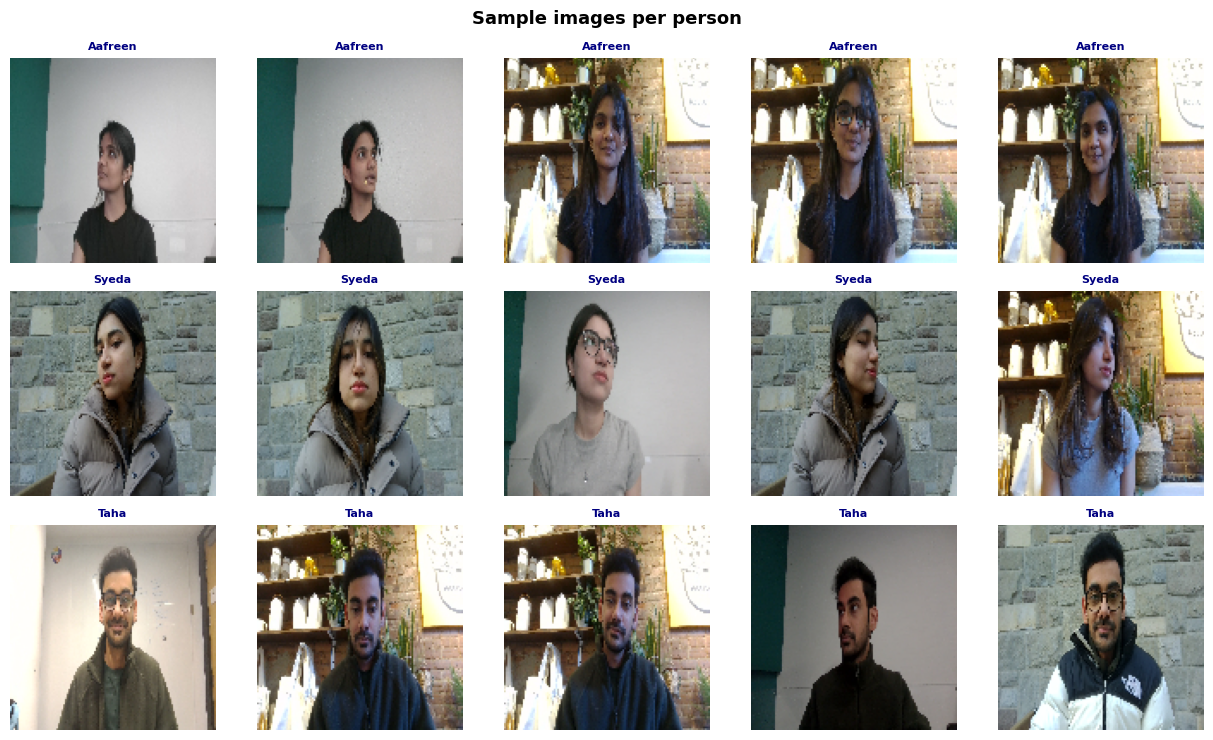

In [ ]:
def preview_samples(dataset_dir, person_files, n=5):
    people = list(person_files.keys())
    fig, axes = plt.subplots(len(people), n,
                             figsize=(n * 2.5, len(people) * 2.5))
    fig.suptitle("Sample images per person", fontsize=13, fontweight='bold')

    for row, person in enumerate(people):
        files = person_files[person][:n]
        for col in range(n):
            ax = axes[row][col] if len(people) > 1 else axes[col]
            if col < len(files):
                img = cv2.imread(os.path.join(dataset_dir, files[col]))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (120, 120))
                    ax.imshow(img)
                ax.set_title(person, fontsize=8, fontweight='bold', color='navy')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

preview_samples(DATASET_DIR, person_files)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Helper functions
# ─────────────────────────────────────────────────────────────────

In [ ]:
def detect_and_crop(img_bgr, detector, padding=0.15):
    """Detects largest face, adds padding, returns crop. None if no face."""
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = detector.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5,
        minSize=(40, 40), flags=cv2.CASCADE_SCALE_IMAGE
    )
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    H, W = img_bgr.shape[:2]
    px, py = int(w * padding), int(h * padding)
    x1, y1 = max(0, x - px),     max(0, y - py)
    x2, y2 = min(W, x + w + px), min(H, y + h + py)
    return img_bgr[y1:y2, x1:x2]


def augment(face_bgr):
    """Returns 7 variants. Applied to train set only."""
    variants = [face_bgr.copy()]
    h, w     = face_bgr.shape[:2]
    ctr      = (w // 2, h // 2)

    # Horizontal flip
    variants.append(cv2.flip(face_bgr, 1))

    # Rotations
    for angle in (12, -12):
        M = cv2.getRotationMatrix2D(ctr, angle, 1.0)
        variants.append(cv2.warpAffine(face_bgr, M, (w, h),
                                       borderMode=cv2.BORDER_REFLECT))
    # Brightness
    for delta in (30, -30):
        shifted = np.clip(face_bgr.astype(np.int16) + delta,
                          0, 255).astype(np.uint8)
        variants.append(shifted)

    # Zoom
    zf = 0.85
    cx, cy = w // 2, h // 2
    cw, ch = int(w * zf), int(h * zf)
    x1, y1 = max(0, cx - cw // 2), max(0, cy - ch // 2)
    x2, y2 = min(w, x1 + cw),      min(h, y1 + ch)
    zoomed  = cv2.resize(face_bgr[y1:y2, x1:x2], (w, h),
                         interpolation=cv2.INTER_AREA)
    variants.append(zoomed)

    return variants


def split_files(file_list, train_r=0.70, val_r=0.15, seed=42):
    random.seed(seed)
    shuffled = file_list.copy()
    random.shuffle(shuffled)
    n       = len(shuffled)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    return (shuffled[:n_train],
            shuffled[n_train:n_train + n_val],
            shuffled[n_train + n_val:])

print(" Helper functions ready.")


 Helper functions ready.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Run the full preprocessing pipeline
# ─────────────────────────────────────────────────────────────────

In [ ]:
def run_pipeline(dataset_dir, person_files):
    detector = cv2.CascadeClassifier(CASCADE_PATH)
    if detector.empty():
        raise RuntimeError("❌ Haar cascade failed to load.")

    saved   = 0
    skipped = 0
    no_face = []

    for person, filenames in person_files.items():
        train_f, val_f, test_f = split_files(
            filenames, TRAIN_RATIO, VAL_RATIO, RANDOM_SEED
        )

        for split, flist, do_aug in [
            ("train", train_f, True),
            ("val",   val_f,   False),
            ("test",  test_f,  False),
        ]:
            out_dir = Path(LOCAL_OUT) / split / person
            out_dir.mkdir(parents=True, exist_ok=True)

            for filename in flist:
                raw_path = os.path.join(dataset_dir, filename)

                img = cv2.imread(raw_path)
                if img is None:
                    print(f"   ⚠️  Cannot read: {filename}")
                    skipped += 1
                    continue

                face = detect_and_crop(img, detector)
                if face is None:
                    no_face.append(filename)
                    skipped += 1
                    continue

                # Resize
                face = cv2.resize(face, IMG_SIZE, interpolation=cv2.INTER_AREA)

                # Save variants (augmented for train, original only for val/test)
                variants = augment(face) if do_aug else [face]
                stem     = Path(filename).stem

                for i, v in enumerate(variants):
                    suffix   = f"_aug{i}" if i > 0 else ""
                    out_path = out_dir / f"{stem}{suffix}.png"
                    cv2.imwrite(str(out_path), v)
                    saved += 1


    print(f"\n{'─'*50}")
    print(f"✅ Pipeline complete!")
    print(f"   Images saved   : {saved}")
    print(f"   Images skipped : {skipped}")
    if no_face:
        print(f"\n⚠️  No face detected in ({len(no_face)} images):")
        for f in no_face:
            print(f"      {f}")
    print(f"\n📂 Split breakdown:")
    for split in ["train", "val", "test"]:
        split_path = Path(LOCAL_OUT) / split
        if not split_path.exists():
            continue
        people = sorted([p.name for p in split_path.iterdir() if p.is_dir()])
        total  = sum(len(list((split_path / p).glob("*.png"))) for p in people)
        print(f"\n   {split.upper()} ({total} images)")
        for p in people:
            count = len(list((split_path / p).glob("*.png")))
            print(f"      └─ {p}: {count}")
    print(f"{'─'*50}")

run_pipeline(DATASET_DIR, person_files)


──────────────────────────────────────────────────
✅ Pipeline complete!
   Images saved   : 349
   Images skipped : 4

⚠️  No face detected in (4 images):
      Aafreen_3.jpg
      Syeda_5.jpg
      Syeda_12.jpg
      Taha_22.jpg

📂 Split breakdown:

   TRAIN (329 images)
      └─ Aafreen: 119
      └─ Syeda: 105
      └─ Taha: 105

   VAL (8 images)
      └─ Aafreen: 3
      └─ Syeda: 2
      └─ Taha: 3

   TEST (12 images)
      └─ Aafreen: 5
      └─ Syeda: 3
      └─ Taha: 4
──────────────────────────────────────────────────


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Save processed dataset to Drive
# ─────────────────────────────────────────────────────────────────

In [ ]:
if os.path.exists(DRIVE_OUT):
    shutil.rmtree(DRIVE_OUT)

shutil.copytree(LOCAL_OUT, DRIVE_OUT)
print(f"✅ Processed dataset saved to Drive:")
print(f"   {DRIVE_OUT}")
print(f"   Train : {DRIVE_OUT}/train/")
print(f"   Val   : {DRIVE_OUT}/val/")
print(f"   Test  : {DRIVE_OUT}/test/")

✅ Processed dataset saved to Drive:
   /content/drive/MyDrive/Applied AI/processed
   Train : /content/drive/MyDrive/Applied AI/processed/train/
   Val   : /content/drive/MyDrive/Applied AI/processed/val/
   Test  : /content/drive/MyDrive/Applied AI/processed/test/


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Preview processed results
# ─────────────────────────────────────────────────────────────────

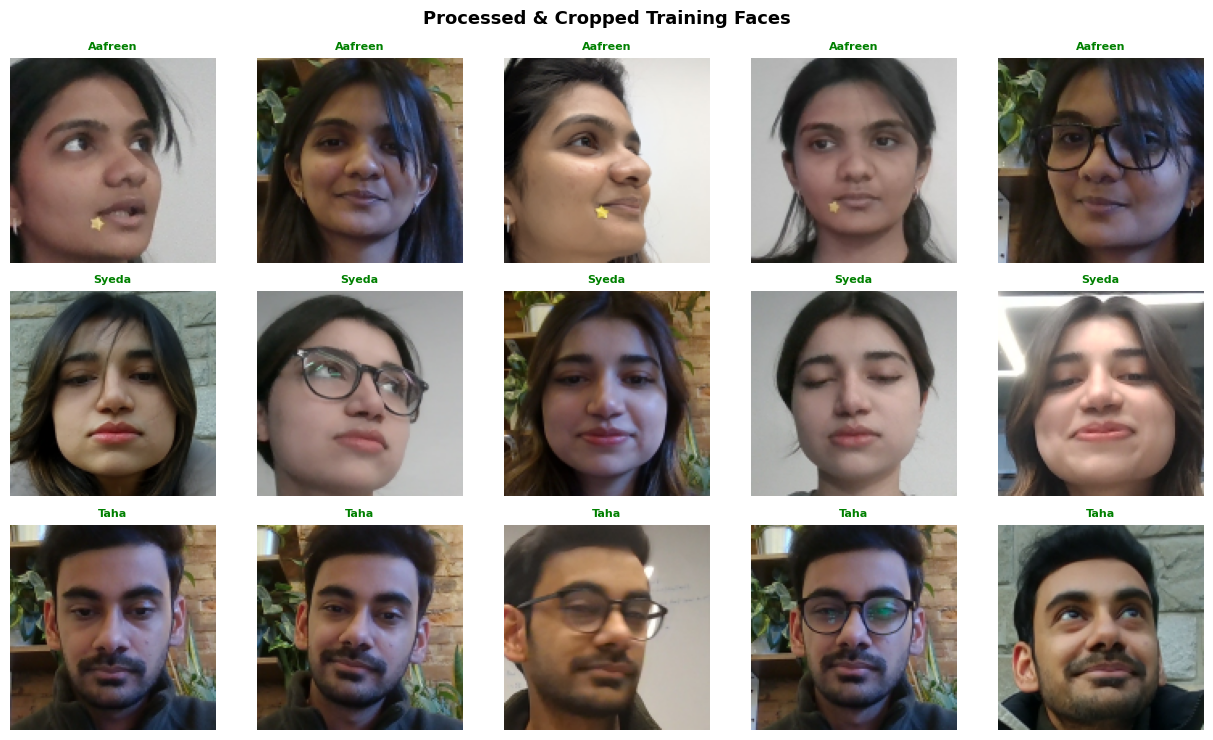

In [ ]:
def preview_processed(n_per_person=5):
    train_path = Path(LOCAL_OUT) / "train"
    people     = sorted([p.name for p in train_path.iterdir() if p.is_dir()])
    fig, axes  = plt.subplots(len(people), n_per_person,
                              figsize=(n_per_person * 2.5, len(people) * 2.5))
    fig.suptitle("Processed & Cropped Training Faces", fontsize=13, fontweight='bold')

    for row, person in enumerate(people):
        # show original (no aug) images only for clarity
        imgs = [f for f in sorted((train_path / person).glob("*.png"))
                if "aug" not in f.name][:n_per_person]
        for col in range(n_per_person):
            ax = axes[row][col] if len(people) > 1 else axes[col]
            if col < len(imgs):
                img = cv2.imread(str(imgs[col]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(person, fontsize=8, fontweight='bold', color='green')
            ax.axis('off')

    plt.tight_layout()
    plt.show()
    #print("✅ If faces look clean and cropped, preprocessing is successful!")
    #print("   Pixel values are 0–255. Tell your teammate to divide by 255.0 in their DataLoader.")

preview_processed()


# 2. Training

# 3. Testing